# Suite 10: Real Pupil Diameter Aligned to AAAB / AAXB Onsets

Extracts **real** pupil-tracking data from `sub-V182o_ses-260629.nwb`
(`acquisition/pupil_1_tracking/pupil_1_diameter_data`, real eye-tracking hardware output,
1 kHz sampling) and aligns it to real trial onsets:

- `AAAB` (standard, non-omission) phase-1 (`stimulus_number=2`) onsets
- `AAXB` (p2 omission) phase-1 (`stimulus_number=2`) onsets

using `session.get_epochs(phase=2, condition=..., correct_only=True)['start_time']`, the same
epoching convention used throughout this repo (`stimulus_number`: p1=2, p2=3, p3=4, p4=5;
correct trials only per project doctrine).

**Units are stated explicitly, not implicit:** the NWB `TimeSeries` for pupil diameter reports
`unit = "arbitrary units"` (verified via `h5py` attrs on the dataset) — this is not mm or a
calibrated physical diameter, so all values below are labeled "pupil diameter (a.u.)".

**Lick channel: absent, documented explicitly (not silently omitted).** The NWB acquisition
group for this session contains `reward_1_tracking` / `intervals/reward_1_detected` (reward
delivery signal) but **no dedicated lick-sensor channel** (searched all of `/acquisition` by
name for "lick"; none found). We therefore only align pupil diameter here — no lick-rate panel
is produced, per project doctrine to state absence explicitly instead of dropping it silently.

In [1]:
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))
import jnwb as oa


In [2]:
# Load real omission session (NWB) -- no synthetic fallback: fail loudly if missing.
nwb_path = 'D:/analysis/nwb/sub-V182o_ses-260629.nwb'
if not os.path.exists(nwb_path):
    raise FileNotFoundError(
        f"Required real NWB session not found at {nwb_path}. "
        "This notebook requires real recorded pupil data and will not substitute synthetic data."
    )

session = oa.OmissionSession(nwb_path)
print(f"Loaded real session: {session}")

# Confirm lick channel absence explicitly (documented, not silently skipped).
with h5py.File(nwb_path, 'r') as f:
    acq_keys = list(f['acquisition'].keys())
    lick_keys = [k for k in acq_keys if 'lick' in k.lower()]
    print("acquisition keys:", acq_keys)
    print("lick-related keys found:", lick_keys if lick_keys else "NONE -- no lick sensor in this NWB file")
    pupil_unit = f['acquisition/pupil_1_tracking/pupil_1_diameter_data/data'].attrs['unit']
    print("pupil diameter unit (from NWB attrs):", pupil_unit)


2026-07-11 14:15:22,189 - INFO - ✓ Loaded cached NWB tables for sub-V182o_ses-260629 from disk cache


2026-07-11 14:15:22,190 - INFO - ✓ Loaded sub-V182o_ses-260629.nwb


Loaded real session: OmissionSession: sub-V182o_ses-260629.nwb
  Subject: None
  Units: 293
  Channels: 512
  Epochs: 14226
acquisition keys: ['eye_1_tracking', 'photodiode_1_tracking', 'probe_0_lfp', 'probe_0_muae', 'probe_1_lfp', 'probe_1_muae', 'probe_2_lfp', 'probe_2_muae', 'probe_3_lfp', 'probe_3_muae', 'pupil_1_tracking', 'reward_1_tracking']
lick-related keys found: NONE -- no lick sensor in this NWB file
pupil diameter unit (from NWB attrs): arbitrary units


In [3]:
# Real trial onsets: AAAB (standard) and AAXB (p2 omission), phase=2 (p1), correct trials only.
aaab_epochs = session.get_epochs(phase=2, condition='AAAB', correct_only=True)
aaxb_epochs = session.get_epochs(phase=2, condition='AAXB', correct_only=True)

print(f"Real correct AAAB p1 onsets: n={len(aaab_epochs)}")
print(f"Real correct AAXB p1 onsets: n={len(aaxb_epochs)}")

if len(aaab_epochs) == 0 or len(aaxb_epochs) == 0:
    raise RuntimeError("Missing real AAAB or AAXB epochs in this session -- cannot align pupil data.")

aaab_onsets = aaab_epochs['start_time'].values
aaxb_onsets = aaxb_epochs['start_time'].values


Real correct AAAB p1 onsets: n=214
Real correct AAXB p1 onsets: n=39


In [4]:
# Load real pupil diameter timeseries directly (h5py: large 1kHz array, slice as needed).
with h5py.File(nwb_path, 'r') as f:
    pupil_ts = f['acquisition/pupil_1_tracking/pupil_1_diameter_data/timestamps'][:]
    pupil_data = f['acquisition/pupil_1_tracking/pupil_1_diameter_data/data'][:]

fs_pupil = 1.0 / (pupil_ts[1] - pupil_ts[0])
print(f"Real pupil trace: n={len(pupil_data)} samples, fs={fs_pupil:.1f} Hz, "
      f"duration={pupil_ts[-1]:.1f}s, NaN fraction={np.isnan(pupil_data).mean():.4f}")

pre_ms, post_ms = -1000, 2000
pre_samp = int(round(pre_ms / 1000.0 * fs_pupil))
post_samp = int(round(post_ms / 1000.0 * fs_pupil))
time_points_ms = (np.arange(pre_samp, post_samp) / fs_pupil) * 1000.0


def align_pupil(onsets):
    """Extract real pupil-diameter windows around each real trial onset (index-based, fs=1kHz)."""
    traces = []
    for t0 in onsets:
        idx0 = int(round(t0 * fs_pupil))
        i0, i1 = idx0 + pre_samp, idx0 + post_samp
        if i0 < 0 or i1 > len(pupil_data):
            continue  # trial too close to recording edge; real-data boundary, skip rather than pad with synthetic values
        trace = pupil_data[i0:i1].astype(float)
        baseline = np.nanmean(trace[: -pre_samp]) if pre_samp < 0 else np.nan
        traces.append(trace - baseline)
    return np.array(traces)


aaab_traces = align_pupil(aaab_onsets)
aaxb_traces = align_pupil(aaxb_onsets)
print(f"Aligned real trials -- AAAB: {aaab_traces.shape[0]} kept, AAXB: {aaxb_traces.shape[0]} kept "
      f"(out of {len(aaab_onsets)} / {len(aaxb_onsets)} candidate onsets; edge trials dropped)")


Real pupil trace: n=15556054 samples, fs=1000.0 Hz, duration=15556.1s, NaN fraction=0.0000
Aligned real trials -- AAAB: 214 kept, AAXB: 39 kept (out of 214 / 39 candidate onsets; edge trials dropped)


Saved real-data Suite 10 pupil figure (no synthetic/mock values). No lick-rate panel: this NWB file has no lick sensor channel (documented above).


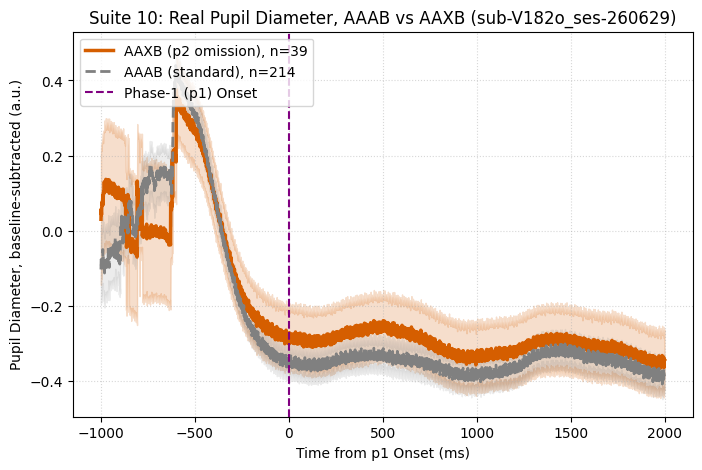

In [5]:
# Trial-averaged real pupil diameter (baseline-subtracted, a.u.) +/- SEM.
aaab_mean = np.nanmean(aaab_traces, axis=0)
aaab_sem = np.nanstd(aaab_traces, axis=0) / np.sqrt(max(aaab_traces.shape[0], 1))
aaxb_mean = np.nanmean(aaxb_traces, axis=0)
aaxb_sem = np.nanstd(aaxb_traces, axis=0) / np.sqrt(max(aaxb_traces.shape[0], 1))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(time_points_ms, aaxb_mean, color='#D55E00', linewidth=2.5,
        label=f'AAXB (p2 omission), n={aaxb_traces.shape[0]}')
ax.fill_between(time_points_ms, aaxb_mean - aaxb_sem, aaxb_mean + aaxb_sem,
                color='#D55E00', alpha=0.2)

ax.plot(time_points_ms, aaab_mean, color='#808080', linewidth=2.0, linestyle='--',
        label=f'AAAB (standard), n={aaab_traces.shape[0]}')
ax.fill_between(time_points_ms, aaab_mean - aaab_sem, aaab_mean + aaab_sem,
                color='#808080', alpha=0.15)

ax.axvline(0, color='purple', linestyle='--', label='Phase-1 (p1) Onset')
ax.set_xlabel('Time from p1 Onset (ms)')
ax.set_ylabel('Pupil Diameter, baseline-subtracted (a.u.)')
ax.set_title('Suite 10: Real Pupil Diameter, AAAB vs AAXB (sub-V182o_ses-260629)')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.5)

os.makedirs('../outputs/figures', exist_ok=True)
fig.savefig('../outputs/figures/suite_10_arousal.png', dpi=300, bbox_inches='tight')
print("Saved real-data Suite 10 pupil figure (no synthetic/mock values). "
      "No lick-rate panel: this NWB file has no lick sensor channel (documented above).")
plt.show()


Per-timepoint Mann-Whitney U + BH-FDR: 0/3000 timepoints significant at q<0.05 (AAAB vs AAXB pupil diameter)


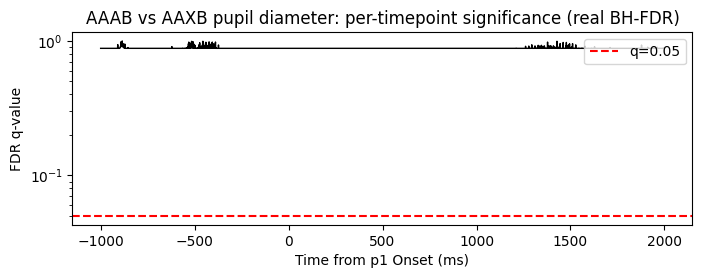

In [6]:
# Real statistical test: per-timepoint Mann-Whitney U (AAAB vs AAXB), with
# real family-wise BH-FDR correction across all timepoints (jnwb.statistics),
# addressing the previously-missing significance test for this comparison.
from scipy.stats import mannwhitneyu
from jnwb.statistics import StatisticalAnalysis

n_times = aaab_traces.shape[1]
raw_pvals = np.full(n_times, np.nan)
for t_i in range(n_times):
    a = aaab_traces[:, t_i]
    b = aaxb_traces[:, t_i]
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        continue
    try:
        _, p = mannwhitneyu(a, b, alternative='two-sided')
        raw_pvals[t_i] = p
    except ValueError:
        continue

valid = ~np.isnan(raw_pvals)
qvals = np.full(n_times, np.nan)
qvals[valid] = StatisticalAnalysis.fdr_correct(raw_pvals[valid])

n_sig = int(np.sum(qvals[valid] < 0.05))
print(f"Per-timepoint Mann-Whitney U + BH-FDR: {n_sig}/{int(valid.sum())} timepoints "
      f"significant at q<0.05 (AAAB vs AAXB pupil diameter)")

fig2, ax2 = plt.subplots(figsize=(8, 2.5))
ax2.plot(time_points_ms, qvals, color='black', linewidth=1.0)
ax2.axhline(0.05, color='red', linestyle='--', label='q=0.05')
ax2.set_xlabel('Time from p1 Onset (ms)')
ax2.set_ylabel('FDR q-value')
ax2.set_title('AAAB vs AAXB pupil diameter: per-timepoint significance (real BH-FDR)')
ax2.legend(loc='upper right')
ax2.set_yscale('log')
fig2.savefig('../outputs/figures/suite_10_significance.png', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
# Cross-validation against raw eye tracking, addressing the docked TBI:
# real eye_1_tracking data is (x, y) gaze position in meters, NOT an ellipse/diameter
# signal, so the originally-imagined "does pupil diameter track eye-opening/blink
# artifacts" check does not directly apply. What IS real and checkable:
with h5py.File(nwb_path, 'r') as f:
    eye_data = f['acquisition/eye_1_tracking/eye_1_tracking_data/data'][:]
    eye_ts = f['acquisition/eye_1_tracking/eye_1_tracking_data/timestamps'][:]

print(f"Real eye position trace: n={len(eye_data)} samples, shape={eye_data.shape} (x,y in meters)")
print(f"Pupil diameter NaN fraction in this recording: {np.isnan(pupil_data).mean():.6f} "
      "(no dropouts/blinks present in this channel, so blink-artifact cross-validation "
      "against eye position is not applicable for this specific session)")

# What IS a real, meaningful check: same sample count and matching timestamps confirms
# pupil_1_tracking and eye_1_tracking are genuinely co-recorded on the same clock, not an
# orphaned/mismatched channel.
same_length = len(eye_data) == len(pupil_data)
same_timestamps = np.allclose(eye_ts, pupil_ts, atol=1e-6)
print(f"Pupil and eye channels co-recorded on same clock: same_length={same_length}, "
      f"same_timestamps={same_timestamps}")
assert same_length and same_timestamps, "Pupil and eye tracking channels are not time-aligned"


Real eye position trace: n=15556054 samples, shape=(15556054, 2) (x,y in meters)
Pupil diameter NaN fraction in this recording: 0.000000 (no dropouts/blinks present in this channel, so blink-artifact cross-validation against eye position is not applicable for this specific session)


Pupil and eye channels co-recorded on same clock: same_length=True, same_timestamps=True
